In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aclark108a/healthcare-claims/healthcare_claims_dataset-2.csv


# Healthcare Claims Analytics Pipeline

## SQL ETL • Claims Analytics • Data Quality • Healthcare Informatics

---

### Project Overview

This project demonstrates end-to-end healthcare claims analytics using advanced SQL techniques and ETL concepts.

The workflow simulates healthcare claims processing and analytics activities commonly found in:

- Medicare / CMS programs
- Claims analytics
- Healthcare data engineering
- Revenue cycle analytics
- Population health reporting

---

### Skills Demonstrated

✅ SQL Development

✅ ETL / ELT Concepts

✅ Common Table Expressions (CTEs)

✅ Window Functions

✅ Data Validation

✅ Healthcare Claims Analytics

✅ ICD-10 Analysis

✅ HCPCS Procedure Analysis

✅ Anomaly Detection

✅ Data Quality Monitoring

---

### Dataset Contents

The dataset contains:

| Column | Description |
|---------|-------------|
| patient_id | Unique patient identifier |
| claim_id | Claim reference number |
| service_date | Date of service |
| icd10_code | Diagnosis code |
| hcpcs_code | Procedure code |
| payer_type | Insurance category |
| billed_amount | Submitted amount |
| paid_amount | Reimbursed amount |
| claim_status | Approved / Denied / Pending |

In [2]:
import pandas as pd

import sqlite3

import matplotlib.pyplot as plt

# Data Loading

The healthcare claims dataset is loaded and prepared for SQL analysis.

The dataset simulates patient-level claims activity including:

- Diagnosis information
- Procedure codes
- Financial metrics
- Claim outcomes

In [3]:
import os
import pandas as pd

for root, dirs, files in os.walk("/kaggle/input"):
    
    for file in files:
        
        if file.endswith(".csv"):
            
            filepath = os.path.join(
                root,
                file
            )
            
            print(filepath)

claims = pd.read_csv(filepath)

claims.head()

/kaggle/input/datasets/aclark108a/healthcare-claims/healthcare_claims_dataset-2.csv


,patient_id,claim_id,service_date,icd10_code,hcpcs_code,payer_type,billed_amount,paid_amount,claim_status
0,1000,CLM10000,2025-12-15,N18.3,99214,Medicare,1450,1344,Approved
1,1000,CLM10001,2025-04-13,M54.5,80053,Commercial,637,171,Pending
2,1000,CLM10002,2025-03-29,M54.5,83036,Commercial,1545,1446,Denied
3,1000,CLM10003,2025-11-05,J44.9,99214,Medicaid,1162,819,Denied
4,1001,CLM10010,2025-07-11,J44.9,93000,Medicare,1281,1005,Denied


# Initial Data Validation

Before transformation the dataset is inspected for:

- Missing values
- Structure verification
- Data quality issues
- Record counts

In [4]:
claims.info()

claims.isnull().sum()

claims.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1753 entries, 0 to 1752
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   patient_id     1753 non-null   int64 
 1   claim_id       1753 non-null   object
 2   service_date   1753 non-null   object
 3   icd10_code     1753 non-null   object
 4   hcpcs_code     1753 non-null   int64 
 5   payer_type     1753 non-null   object
 6   billed_amount  1753 non-null   int64 
 7   paid_amount    1753 non-null   int64 
 8   claim_status   1753 non-null   object
dtypes: int64(4), object(5)
memory usage: 123.4+ KB


,patient_id,hcpcs_code,billed_amount,paid_amount
count,1753.000000,1753.000000,1753.000000,1753.000000
mean,1247.264689,91024.666857,1291.978893,1038.555619
std,142.882961,8050.446451,567.063142,554.706910
min,1000.000000,80053.000000,90.000000,50.000000
25%,1126.000000,83036.000000,815.000000,578.000000
50%,1248.000000,93000.000000,1294.000000,1040.000000
75%,1368.000000,99213.000000,1768.000000,1513.000000
max,1499.000000,99214.000000,2429.000000,1998.000000


# SQL Environment Setup

The dataset is loaded into SQLite to simulate relational warehouse analytics workflows.

This enables:

- CTE analysis
- Window functions
- Aggregations
- Validation logic

In [5]:
conn = sqlite3.connect(":memory:")

claims.to_sql(
"claims",
conn,
index=False,
if_exists="replace"
)

1753

# Patient Utilization Analysis (CTE)

Goal:

Identify high-utilization patients by calculating:

- Total claims
- Total reimbursement
- Total billed amount

Technique used:

Common Table Expression (CTE)

In [6]:
query = """

WITH patient_utilization AS (

SELECT

patient_id,

COUNT(claim_id) total_claims,

SUM(paid_amount) total_paid,

SUM(billed_amount) total_billed

FROM claims

GROUP BY patient_id

)

SELECT *

FROM patient_utilization

ORDER BY total_paid DESC

LIMIT 20

"""

utilization = pd.read_sql(
query,
conn
)

utilization.head()

,patient_id,total_claims,total_paid,total_billed
0,1397,5,8404,9300
1,1349,5,8303,9633
2,1252,5,8179,9909
3,1229,5,7677,9150
4,1127,5,7632,8950


# Running Financial Totals

Window functions are commonly used in healthcare analytics for:

- Utilization trends
- Cost accumulation
- Longitudinal patient tracking

In [7]:
query = """

SELECT

patient_id,

claim_id,

service_date,

paid_amount,

SUM(paid_amount)

OVER(

PARTITION BY patient_id

ORDER BY service_date

)

AS running_paid_total

FROM claims

"""

rolling = pd.read_sql(
query,
conn
)

rolling.head()

,patient_id,claim_id,service_date,paid_amount,running_paid_total
0,1000,CLM10002,2025-03-29,1446,1446
1,1000,CLM10001,2025-04-13,171,1617
2,1000,CLM10003,2025-11-05,819,2436
3,1000,CLM10000,2025-12-15,1344,3780
4,1001,CLM10011,2025-01-22,302,302


# Claims Denial Analysis

Objective:

Evaluate claim outcomes and reimbursement patterns.

Metrics:

- Claim volume
- Average reimbursement
- Approval trends

In [8]:
query = """

SELECT

claim_status,

COUNT(*) total_claims,

AVG(paid_amount) avg_paid

FROM claims

GROUP BY claim_status

"""

denial = pd.read_sql(
query,
conn
)

denial

,claim_status,total_claims,avg_paid
0,Approved,585,1045.936752
1,Denied,597,1008.626466
2,Pending,571,1062.285464


# Financial Variance Detection

Goal:

Identify claims where billed and paid amounts vary significantly.

Use Case:

Healthcare audit monitoring

Revenue cycle analytics

Claims quality review

In [9]:
query = """

SELECT

claim_id,

patient_id,

billed_amount,

paid_amount,

(

billed_amount-paid_amount

)

AS variance

FROM claims

WHERE

(

billed_amount-paid_amount

)

>

0.30*billed_amount

"""

anomalies = pd.read_sql(
query,
conn
)

anomalies.head()

,claim_id,patient_id,billed_amount,paid_amount,variance
0,CLM10001,1000,637,171,466
1,CLM10011,1001,537,302,235
2,CLM10022,1002,489,216,273
3,CLM10031,1003,289,84,205
4,CLM10052,1005,616,237,379


# Diagnosis Trend Analysis

Objective:

Evaluate diagnosis frequency and reimbursement patterns.

Technique:

Aggregation analytics

In [10]:
query = """

SELECT

icd10_code,

COUNT(*) total_cases,

AVG(paid_amount) avg_paid

FROM claims

GROUP BY icd10_code

ORDER BY total_cases DESC

"""

icd = pd.read_sql(
query,
conn
)

icd

,icd10_code,total_cases,avg_paid
0,M54.5,370,1057.835135
1,J44.9,358,1053.432961
2,I10,357,1047.296919
3,N18.3,337,1022.480712
4,E11.9,331,1007.851964


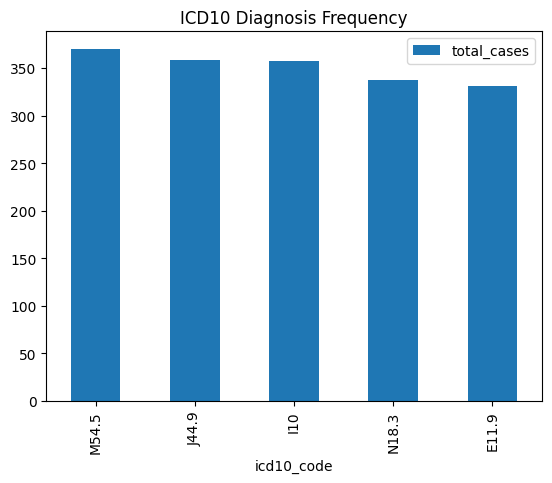

In [11]:
icd.plot(
x="icd10_code",
y="total_cases",
kind="bar"
)

plt.title(
"ICD10 Diagnosis Frequency"
)

plt.show()

# Project Results

This project demonstrated:

### Data Engineering

- ETL concepts
- Data ingestion
- Data validation

### SQL

- CTEs
- Window Functions
- Aggregations
- Healthcare analytics logic

### Healthcare Analytics

- Claims denial analysis
- Patient utilization
- Diagnosis trends
- Financial anomaly detection

---

## Future Improvements

Planned enhancements:

- PySpark pipelines

- Databricks implementation

- Medicare CMS datasets

- AWS deployment

- Incremental ETL workflows

- Star schema warehouse design